# 03 — VisText-Mosquito (Breeding Place Detection): Cleaning & EDA

In [17]:
import os, hashlib
from collections import Counter
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import os, yaml

In [18]:


def read_data_yaml(root):
    """Reads a Roboflow-style data.yaml and returns the class name list."""
    yaml_path = os.path.join(root, "data.yaml")
    if not os.path.isfile(yaml_path):
        print(f"[!] No data.yaml found in {root}")
        return None
    with open(yaml_path) as f:
        data = yaml.safe_load(f)
    return data.get("names")

def detect_splits(root):
    """Finds split folders (train/valid/test, or train/val/test, etc.) that contain images+labels."""
    found = {}
    for name in os.listdir(root):
        split_dir = os.path.join(root, name)
        if not os.path.isdir(split_dir):
            continue
        img_dir = os.path.join(split_dir, "images")
        lbl_dir = os.path.join(split_dir, "labels")
        if os.path.isdir(img_dir) and os.path.isdir(lbl_dir):
            found[name] = {"images": img_dir, "labels": lbl_dir}
    return found

ROOT = os.path.join("data/raw/VisText-Mosquito A Multimodal Dataset for Mosquito", "Breeding Place Detection")
splits = detect_splits(ROOT)
CLASS_NAMES = read_data_yaml(ROOT)
print("Splits found:", list(splits.keys()))
print("Classes:", CLASS_NAMES)

if not splits:
    print("[!] No train/valid/test/images+labels layout detected directly under:")
    print("   ", ROOT)
    print("    Open the 'Breeding Place Detection' folder in File Explorer and check its real layout,")
    print("    then adjust ROOT above (e.g. it may need an extra subfolder in the path).")

Splits found: ['test', 'train', 'valid']
Classes: ['Bottle', 'Coconut-Exocarp', 'Drain-Inlet', 'Tire', 'Vase']


## 1. Corrupt image check

In [19]:
def find_corrupt_images(img_dir):
    bad = []
    for f in os.listdir(img_dir):
        path = os.path.join(img_dir, f)
        try:
            Image.open(path).verify()
        except Exception:
            bad.append(path)
    return bad

for split, dirs in splits.items():
    print(split, "-> corrupt images:", len(find_corrupt_images(dirs["images"])))

test -> corrupt images: 0
train -> corrupt images: 0
valid -> corrupt images: 0


## 2. Duplicate check

In [20]:
def find_duplicates(img_dir):
    seen, dupes = {}, []
    for f in os.listdir(img_dir):
        path = os.path.join(img_dir, f)
        h = hashlib.md5(open(path, "rb").read()).hexdigest()
        if h in seen:
            dupes.append(path)
        else:
            seen[h] = path
    return dupes

for split, dirs in splits.items():
    print(split, "-> exact duplicates:", len(find_duplicates(dirs["images"])))

test -> exact duplicates: 0
train -> exact duplicates: 52
valid -> exact duplicates: 0


## 3. Image/label pairing check

In [21]:
for split, dirs in splits.items():
    imgs = set(f.rsplit(".",1)[0] for f in os.listdir(dirs["images"]))
    lbls = set(f.rsplit(".",1)[0] for f in os.listdir(dirs["labels"]))
    print(split, "-> images without labels:", len(imgs-lbls), "| labels without images:", len(lbls-imgs))

test -> images without labels: 0 | labels without images: 0
train -> images without labels: 0 | labels without images: 0
valid -> images without labels: 0 | labels without images: 0


## 4. EDA — objects per class

In [22]:
def count_classes(dirs):
    counts = Counter()
    for f in os.listdir(dirs["labels"]):
        for line in open(os.path.join(dirs["labels"], f)):
            if line.strip():
                cid = int(line.split()[0])
                name = CLASS_NAMES[cid] if CLASS_NAMES else str(cid)
                counts[name] += 1
    return counts

vt_counts = {split: count_classes(dirs) for split, dirs in splits.items()}
df_vt = pd.DataFrame(vt_counts).fillna(0).astype(int)
df_vt

,test,train,valid
Tire,115,1635,119
Drain-Inlet,54,1164,135
Vase,104,2193,206
Bottle,50,1194,100
Coconut-Exocarp,101,1939,171


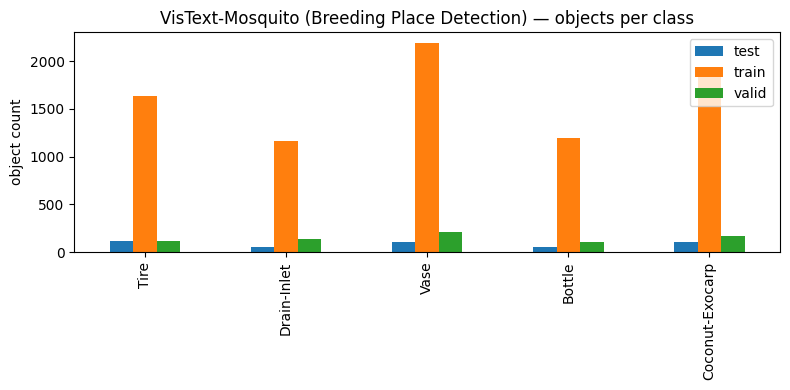

In [23]:
if not df_vt.empty:
    df_vt.plot(kind="bar", figsize=(8,4), title="VisText-Mosquito (Breeding Place Detection) — objects per class")
    plt.ylabel("object count")
    plt.tight_layout()
    plt.savefig("data/charts/vistext_class_distribution.png", dpi=150)
    plt.show()

## 5. Blur & brightness spot-check on a random sample

In [24]:
import cv2, random

def blur_score(path):
    return cv2.Laplacian(cv2.imread(path, cv2.IMREAD_GRAYSCALE), cv2.CV_64F).var()

def brightness_score(path):
    return cv2.imread(path, cv2.IMREAD_GRAYSCALE).mean()

if "train" in splits:
    sample_files = random.sample(os.listdir(splits["train"]["images"]),
                                  min(20, len(os.listdir(splits["train"]["images"]))))
    rows = []
    for f in sample_files:
        p = os.path.join(splits["train"]["images"], f)
        rows.append({"file": f, "blur": blur_score(p), "brightness": brightness_score(p)})
    df_quality = pd.DataFrame(rows)
    print(df_quality.describe())
    risky = df_quality[(df_quality.blur < 100) | (df_quality.brightness < 40) | (df_quality.brightness > 220)]
    print("\nRisky images in this sample:", len(risky))
    risky

              blur  brightness
count    20.000000   20.000000
mean   1778.833617  111.911350
std    1552.252651   41.955838
min      42.772456   10.625229
25%     797.430977   92.215396
50%    1388.564154  118.021650
75%    1850.774007  148.798101
max    6444.406060  168.219500

Risky images in this sample: 2
